### Fake Job Detection

Developed an NLP-based fake job detection system using machine learning to classify fraudulent and genuine job postings from textual job descriptions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\NLP Projects\Fake_job_detection_nlp\fake_job_postings.csv")

In [5]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [6]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [7]:
df=df[["description","fraudulent"]]

In [8]:
df=df.dropna()

In [9]:
df.columns

Index(['description', 'fraudulent'], dtype='object')

In [10]:
df.head()

,description,fraudulent
0,"Food52, a fast-growing, James Beard Award-winn...",0
1,Organised - Focused - Vibrant - Awesome!Do you...,0
2,"Our client, located in Houston, is actively se...",0
3,THE COMPANY: ESRI – Environmental Systems Rese...,0
4,JOB TITLE: Itemization Review ManagerLOCATION:...,0


In [11]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      865
Name: count, dtype: int64

In [12]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["description"].apply(clean_text)

In [13]:
df

,description,fraudulent,clean_text
0,"Food52, a fast-growing, James Beard Award-winn...",0,food a fastgrowing james beard awardwinning on...
1,Organised - Focused - Vibrant - Awesome!Do you...,0,organised focused vibrant awesomedo you have a...
2,"Our client, located in Houston, is actively se...",0,our client located in houston is actively seek...
3,THE COMPANY: ESRI – Environmental Systems Rese...,0,the company esri environmental systems researc...
4,JOB TITLE: Itemization Review ManagerLOCATION:...,0,job title itemization review managerlocation f...
...,...,...,...
17875,Just in case this is the first time you’ve vis...,0,just in case this is the first time youve visi...
17876,The Payroll Accountant will focus primarily on...,0,the payroll accountant will focus primarily on...
17877,Experienced Project Cost Control Staff Enginee...,0,experienced project cost control staff enginee...
17878,Nemsia Studios is looking for an experienced v...,0,nemsia studios is looking for an experienced v...


In [14]:
df["char_count"]=df["description"].str.len()

In [15]:
df.head()

,description,fraudulent,clean_text,char_count
0,"Food52, a fast-growing, James Beard Award-winn...",0,food a fastgrowing james beard awardwinning on...,905
1,Organised - Focused - Vibrant - Awesome!Do you...,0,organised focused vibrant awesomedo you have a...,2077
2,"Our client, located in Houston, is actively se...",0,our client located in houston is actively seek...,355
3,THE COMPANY: ESRI – Environmental Systems Rese...,0,the company esri environmental systems researc...,2600
4,JOB TITLE: Itemization Review ManagerLOCATION:...,0,job title itemization review managerlocation f...,1520


C:\Users\DELL\AppData\Local\Temp\ipykernel_10036\1367858664.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["char_count"])


<Axes: xlabel='char_count', ylabel='Density'>

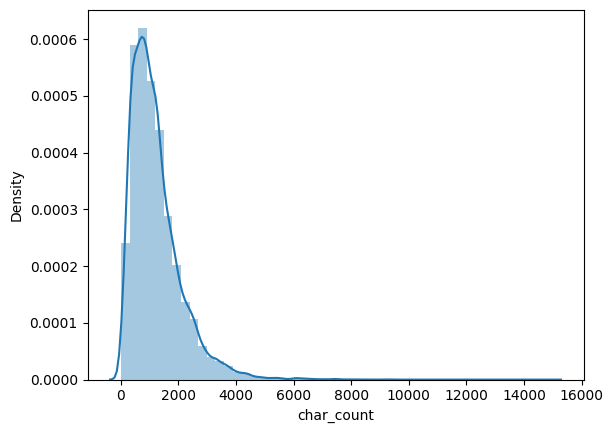

In [16]:
sns.distplot(df["char_count"])

In [17]:
import scipy.stats as stats

((array([-3.95189095, -3.73434308, -3.61524252, ...,  3.61524252,
          3.73434308,  3.95189095], shape=(17879,)),
  array([    6,     6,     6, ..., 12302, 12604, 14907], shape=(17879,))),
 (np.float64(822.7295077254826),
  np.float64(1218.0725432071147),
  np.float64(0.9192801135292022)))

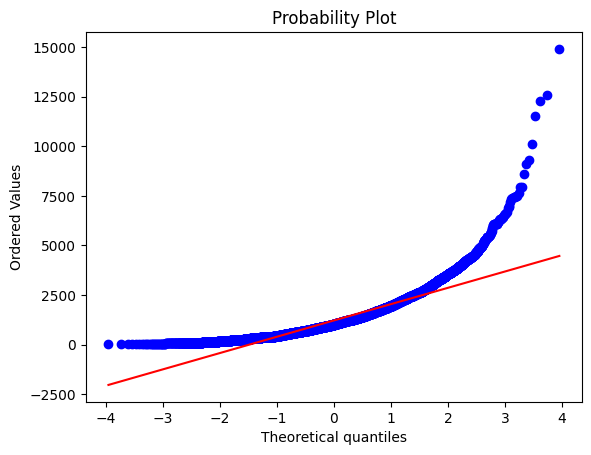

In [18]:
stats.probplot(df["char_count"],dist="norm",plot=plt)

In [19]:
Fake_char_count=df[df["fraudulent"]==1]["char_count"]
Real_char_count=df[df["fraudulent"]==0]["char_count"]

In [20]:
def estimate_CLT_Fake_job(data,no_of_samples,sample_size):
  sample_mean = []
  for i in range(no_of_samples):
    sample = np.random.choice(data,sample_size)
    sample_mean.append(np.mean(sample))
  sample_mean_array = np.array(sample_mean)
  return np.mean(sample_mean_array)


In [21]:
data = Fake_char_count
no_of_samples = 1000
sample_size = 30
estimate_CLT_Fake_job(data,no_of_samples,sample_size)

np.float64(1161.1213333333335)

In [22]:
data = Real_char_count
no_of_samples = 1000
sample_size = 30
estimate_CLT_Fake_job(data,no_of_samples,sample_size)

np.float64(1222.3793000000003)

In [23]:
df["words_count"]=df["description"].str.split().apply(len)

C:\Users\DELL\AppData\Local\Temp\ipykernel_10036\2852045227.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["words_count"])


<Axes: xlabel='words_count', ylabel='Density'>

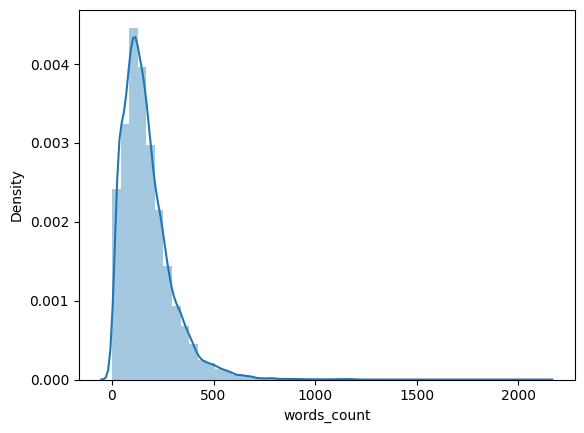

In [24]:
sns.distplot(df["words_count"])

In [25]:
Fake_word_count=df[df["fraudulent"]==1]["words_count"]
Real_word_count=df[df["fraudulent"]==0]["words_count"]

In [26]:
data = Fake_word_count
no_of_samples = 1000
sample_size = 30
estimate_CLT_Fake_job(data,no_of_samples,sample_size)

np.float64(159.1161)

In [27]:
data = Real_word_count
no_of_samples = 1000
sample_size = 30
estimate_CLT_Fake_job(data,no_of_samples,sample_size)

np.float64(170.2744)

In [28]:
df["capital_count"] = df["description"].apply(
    lambda x: sum(1 for char in str(x) if char.isupper())
)

In [29]:
Fake_capital_letter_count=df[df["fraudulent"]==1]["capital_count"]
Real_capital_letter_count=df[df["fraudulent"]==0]["capital_count"]

In [30]:
data = Fake_capital_letter_count
no_of_samples = 1000
sample_size = 30
estimate_CLT_Fake_job(data,no_of_samples,sample_size)

np.float64(46.18476666666666)

In [31]:
data = Real_capital_letter_count
no_of_samples = 1000
sample_size = 30
estimate_CLT_Fake_job(data,no_of_samples,sample_size)

np.float64(37.4395)

In [32]:
df

,description,fraudulent,clean_text,char_count,words_count,capital_count
0,"Food52, a fast-growing, James Beard Award-winn...",0,food a fastgrowing james beard awardwinning on...,905,124,26
1,Organised - Focused - Vibrant - Awesome!Do you...,0,organised focused vibrant awesomedo you have a...,2077,315,65
2,"Our client, located in Houston, is actively se...",0,our client located in houston is actively seek...,355,50,7
3,THE COMPANY: ESRI – Environmental Systems Rese...,0,the company esri environmental systems researc...,2600,346,78
4,JOB TITLE: Itemization Review ManagerLOCATION:...,0,job title itemization review managerlocation f...,1520,168,135
...,...,...,...,...,...,...
17875,Just in case this is the first time you’ve vis...,0,just in case this is the first time youve visi...,1442,226,22
17876,The Payroll Accountant will focus primarily on...,0,the payroll accountant will focus primarily on...,1216,161,23
17877,Experienced Project Cost Control Staff Enginee...,0,experienced project cost control staff enginee...,1291,171,26
17878,Nemsia Studios is looking for an experienced v...,0,nemsia studios is looking for an experienced v...,506,77,17


<Axes: xlabel='fraudulent', ylabel='char_count'>

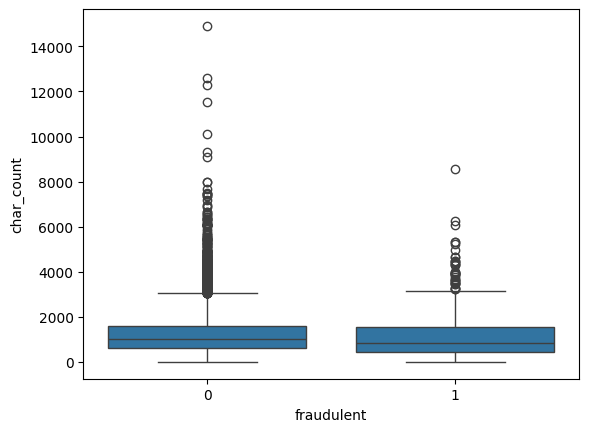

In [33]:
sns.boxplot(x="fraudulent",y="char_count",data=df)

<Axes: xlabel='fraudulent', ylabel='words_count'>

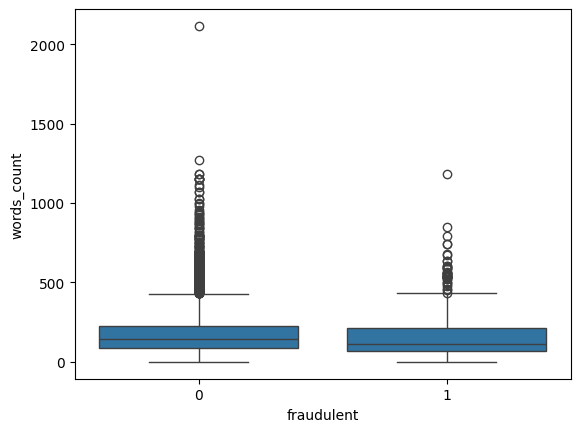

In [34]:
sns.boxplot(x="fraudulent",y="words_count",data=df)

<Axes: xlabel='fraudulent', ylabel='capital_count'>

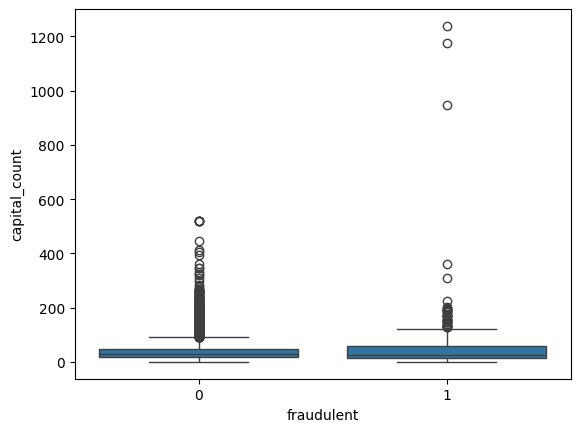

In [35]:
sns.boxplot(x="fraudulent",y="capital_count",data=df)

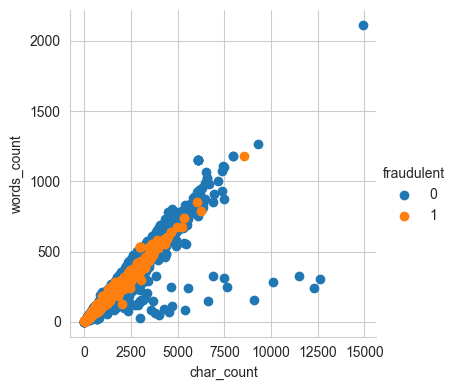

In [36]:
sns.set_style("whitegrid")
sns.FacetGrid(df,hue="fraudulent",height=4).map(plt.scatter,"char_count","words_count").add_legend()
plt.show()#if the char_count and word_count are very high it's a fake news

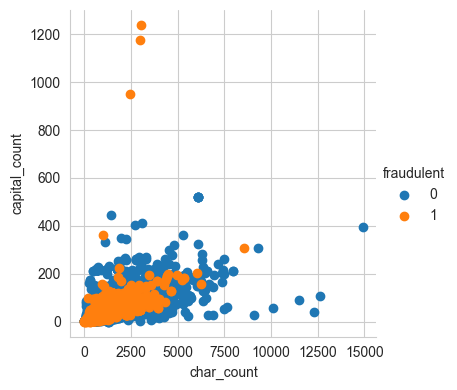

In [37]:
sns.set_style("whitegrid")
sns.FacetGrid(df,hue="fraudulent",height=4).map(plt.scatter,"char_count","capital_count").add_legend()
plt.show()#if the char_count and word_count are very high it's a fake news

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X = df["description"]

In [40]:
y = df["fraudulent"]

In [41]:
xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [42]:
type(xtrain)

pandas.core.series.Series

In [43]:
xtrain_convert = xtrain.astype("str").tolist()

In [44]:
xtest_convert = xtest.astype("str").tolist()

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [46]:
tfidf = TfidfVectorizer(stop_words="english")

In [47]:
xtrain_tfidf = tfidf.fit_transform(xtrain_convert)

In [48]:
xtest_tfidf  = tfidf.transform(xtest_convert)

In [49]:
from sklearn.naive_bayes import MultinomialNB

In [50]:
from sklearn.model_selection import GridSearchCV

In [51]:
mnmodel=MultinomialNB()

In [52]:
params_grid={
    "alpha":[0.1,0.01,1.0,2.0]
}

In [53]:
grid=GridSearchCV(
    estimator=mnmodel,
    param_grid=params_grid,
    cv=5,
    scoring="accuracy"
)

In [54]:
grid.fit(xtrain_tfidf,ytrain)

,estimator,MultinomialNB()
,param_grid,"{'alpha': [0.1, 0.01, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


In [55]:
grid.best_params_

{'alpha': 0.1}

In [56]:
grid.best_score_

np.float64(0.9609173524832386)

In [57]:
multi_model=MultinomialNB(alpha= 0.1)

In [58]:
multi_model.fit(xtrain_tfidf,ytrain)

,alpha,0.1
,force_alpha,True
,fit_prior,True
,class_prior,None


In [59]:
ypred=multi_model.predict(xtest_tfidf)

In [60]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [61]:
accuracy_score(ytest,ypred)

0.9686800894854586

In [62]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.98      0.36      0.53       173

    accuracy                           0.97      3576
   macro avg       0.98      0.68      0.75      3576
weighted avg       0.97      0.97      0.96      3576



In [63]:
confusion_matrix(ytest,ypred)

array([[3402,    1],
       [ 111,   62]])

In [64]:
from sklearn.linear_model import LogisticRegression

In [65]:
model1=LogisticRegression(max_iter=1000)

In [66]:
params_grid1={
    "C":[1.0,0.1,0.01,2.0],
    "penalty":["l1","l2","elasticnet"],
    "solver":["lbfgs","liblinear"]
}

In [67]:
grid2=GridSearchCV(
    estimator=model1,
    param_grid=params_grid1,
    cv=5,
    scoring="accuracy"
)

In [68]:
grid2.fit(xtrain_tfidf,ytrain)

C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\s

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [1.0, 0.1, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [69]:
grid2.best_params_

{'C': 2.0, 'penalty': 'l1', 'solver': 'liblinear'}

In [70]:
grid2.best_score_

np.float64(0.969586701309875)

In [93]:
lr_model =LogisticRegression(C=2.0,penalty="l1",solver="liblinear",max_iter=1000,class_weight="balanced")

In [94]:
lr_model.fit(xtrain_tfidf,ytrain)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,2.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [95]:
ypred1=lr_model.predict(xtest_tfidf)

In [96]:
accuracy_score(ytest,ypred1)

0.9650447427293065

In [97]:
print("Accuracy:", accuracy_score(ytest, ypred1))

Accuracy: 0.9650447427293065


In [98]:
print(confusion_matrix(ytest, ypred1))

[[3306   97]
 [  28  145]]


In [99]:
print(classification_report(ytest, ypred1))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.60      0.84      0.70       173

    accuracy                           0.97      3576
   macro avg       0.80      0.90      0.84      3576
weighted avg       0.97      0.97      0.97      3576



In [100]:
import pickle

with open("model_fake_job.pkl", "wb") as f:
    pickle.dump(lr_model, f)

with open("vectorizer_fake_job.pkl", "wb") as f:
    pickle.dump(tfidf, f)

In [88]:
df[df["fraudulent"] == 0].head(3)

,description,fraudulent,clean_text,char_count,words_count,capital_count
0,"Food52, a fast-growing, James Beard Award-winn...",0,food a fastgrowing james beard awardwinning on...,905,124,26
1,Organised - Focused - Vibrant - Awesome!Do you...,0,organised focused vibrant awesomedo you have a...,2077,315,65
2,"Our client, located in Houston, is actively se...",0,our client located in houston is actively seek...,355,50,7


In [89]:
df[df["fraudulent"] == 1].head(3)

,description,fraudulent,clean_text,char_count,words_count,capital_count
98,"IC&amp;E Technician | Bakersfield, CA Mt. Poso...",1,icampe technician bakersfield ca mt posoprinci...,2245,272,46
144,The group has raised a fund for the purchase o...,1,the group has raised a fund for the purchase o...,337,59,4
173,Technician Instrument &amp; ControlsLocation D...,1,technician instrument amp controlslocation dew...,4447,589,192


In [90]:
# Check label meaning in your dataset

df["fraudulent"].value_counts()

fraudulent
0    17014
1      865
Name: count, dtype: int64

In [91]:
df[df["fraudulent"] == 0][["description"]].head(1)

,description
0,"Food52, a fast-growing, James Beard Award-winn..."


In [101]:
fake_sample = df[df["fraudulent"] == 1]["description"].iloc[0]

vec = tfidf.transform([fake_sample])

print("Prediction:", lr_model.predict(vec)[0])
print("Probability:", lr_model.predict_proba(vec))
print(fake_sample)

Prediction: 1
Probability: [[0.05352364 0.94647636]]
IC&amp;E Technician | Bakersfield, CA Mt. PosoPrincipal Duties and Responsibilities: Calibrates, tests, maintains, troubleshoots, and installs all power plant instrumentation, control systems and electrical equipment.Performs maintenance on motor control centers, motor operated valves, generators, excitation equipment and motors.Performs preventive, predictive and corrective maintenance on equipment, coordinating work with various team members.Designs and installs new equipment and/or system modifications.Troubleshoots and performs maintenance on DC backup power equipment, process controls, programmable logic controls (PLC), and emission monitoring equipment.Uses maintenance reporting system to record time and material use, problem identified and corrected, and further action required; provides complete history of maintenance on equipment.Schedule, coordinate, work with and monitor contractors on specific tasks, as required.Follows s